<a href="https://colab.research.google.com/github/m4tt-nm/martino_DSPN_S26/blob/master/ExerciseSubmissions/13_resampling-methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 13:  Resampling methods

This homework assignment is designed to give you practice with bootstrapping and permutation tests.

You will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measurements from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

In [1]:
install.packages("tidyverse")
library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


---
## 1. Loading & Visualizing the Data (1 point)

Use the `setwd` and `read.csv` functions to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file.

(a) Using the tidyverse tools, create a new dataframe `d1` that only includes the subject ID (`Subject`), gender (`Gender`, self reported at time of data collection), Flanker Task performance (`Flanker_Unadj`), total intracranial volume (`FS_IntraCranial_Vol`), total white matter volume (`FS_Tot_WM_Vol`), and total grey matter volume (`FS_Total_GM_Vol`) variables and remove all _na_ values.

Use the `head` function to look at the first few rows of each data frame.

In [19]:
# WRITE YOUR CODE HERE
d1 <- read.csv("https://raw.githubusercontent.com/m4tt-nm/martino_DSPN_S26/refs/heads/master/Exercise%20datasets/hcp_data/unrestricted_trimmed_1_7_2020_10_50_44.csv")
d1 <- d1 %>%
        select(c("Subject", "Gender", "Flanker_Unadj", "FS_IntraCranial_Vol", "FS_Tot_WM_Vol", "FS_Total_GM_Vol")) %>%
        drop_na() %>%
        mutate(Gender = as.factor(Gender))
head(d1)

,Subject,Gender,Flanker_Unadj,FS_IntraCranial_Vol,FS_Tot_WM_Vol,FS_Total_GM_Vol
,<int>,<fct>,<dbl>,<dbl>,<int>,<int>
1,100206,M,130.42,1864518,543134,807245
2,100307,F,112.56,1512540,407292,664124
3,100408,M,121.18,1684117,500417,726206
4,100610,M,126.53,1816044,512946,762308
5,101006,F,101.85,1437868,429449,579632
6,101107,M,107.04,1512727,416995,665024


(b) Plot grey matter volume (x axis) against intracranial volume (y axis) and Gender (point color).

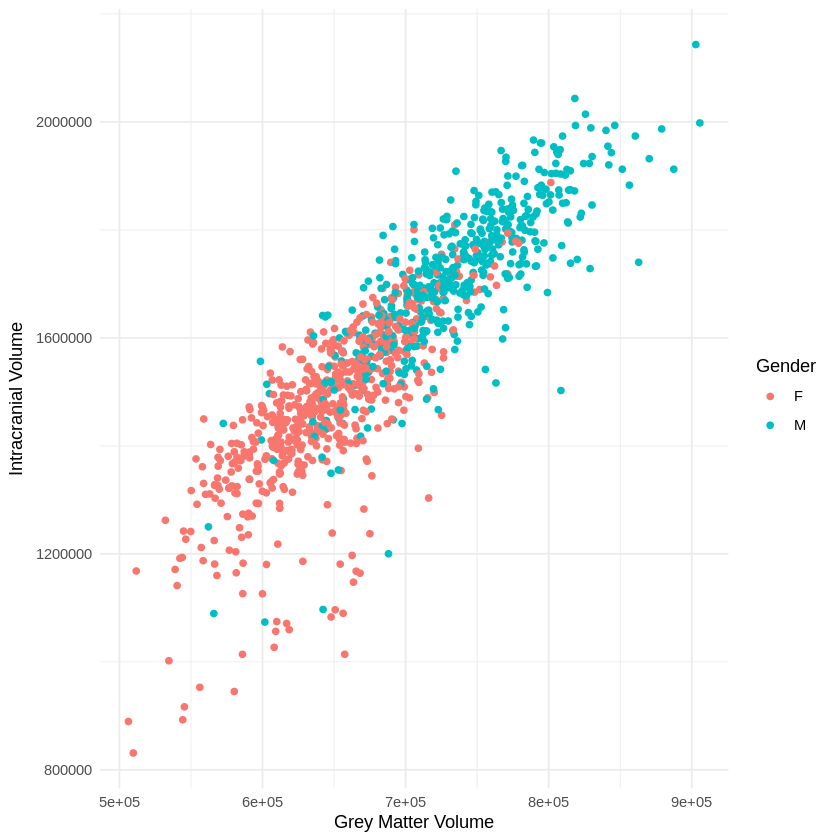

In [20]:
# WRITE YOUR CODE HERE
ggplot(d1, aes(x = FS_Total_GM_Vol, y = FS_IntraCranial_Vol, color = Gender)) +
  geom_point() +
  labs(x = "Grey Matter Volume", y = "Intracranial Volume") +
  theme_minimal()


What patterns do you observe in the scatter plot?

> *Total intracranial volume has a strong positive relationship with grey matter volume. Also, the distribution of both volumes for men and women do not overlap greatly such that men have distinctly higher intracranial and grey matter volumes than women.*
>

---
## 2. Logistic classifier (2 points)

We want to try predicting gender using the neural data you have loaded.

(a) Run a logistic regression model to predict gender from total white matter volume, total grey matter volume, and intracranial volume.

In [21]:
# WRITE YOUR CODE HERE
glm1 <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol,
            data = d1,
            family = "binomial")

summary(glm1)



Call:
glm(formula = Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol, 
    family = "binomial", data = d1)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -2.262e+01  1.347e+00 -16.787  < 2e-16 ***
FS_Tot_WM_Vol        2.140e-06  3.059e-06   0.699    0.484    
FS_Total_GM_Vol      1.959e-05  3.145e-06   6.229 4.70e-10 ***
FS_IntraCranial_Vol  5.020e-06  1.177e-06   4.263 2.01e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1534.13  on 1112  degrees of freedom
Residual deviance:  919.85  on 1109  degrees of freedom
AIC: 927.85

Number of Fisher Scoring iterations: 5


Which factors are significantly associated with gender?

> *Grey matter volume and intracranial volume*
>

(b) Estimate the prediction accuracy of your model (Note: this is the training set accuracy). Set your prediction threshold to 0.5.

In [27]:
# WRITE YOUR CODE HERE
THRESHOLD <- 0.5

d1_preds <- glm1 %>%
predict(type = "response") %>%
as.data.frame()

colnames(d1_preds) <- "predicted_probs"

num_observations <- nrow(d1)

d1_preds$predicted_gender <- rep("F", num_observations)
d1_preds$predicted_gender[d1_preds$predicted_probs > THRESHOLD] <- "M"

confusion <- data.frame(d1_preds$predicted_gender, d1$Gender)
colnames(confusion) <- c("Predicted", "Actual")
table(confusion)

print(paste("Accuracy:",mean(confusion$Predicted == confusion$Actual, na.rm = TRUE)))


         Actual
Predicted   F   M
        F 516 110
        M  90 397

[1] "Accuracy: 0.820305480682839"


What is the prediction accuracy for gender from the full model?

>*~0.82*
>

---
## 3. Bootstrapped accuracy (3 points)

Use bootstrapping to estimate the confidence interval for your model's prediction accuracy. Plot a histogram of the bootstrapped accuracies, and estimate the confidence interval using the standard deviation of the bootstrap distribution.


In [ ]:
# WRITE YOUR CODE HERE



How robust is the prediction accuracy of the full model?

> *Write your response here*
>

---
## 4. Permutation test for grey matter effects (3 points)

Now run a permutation test, with 1000 iterations, to evaluate how much grey matter volume contributes to the prediction accuracy. Compare the prediction accuracy of the full (unpermuted) model with the distribution of accuracies obtained when the grey matter volume variable is permuted, using a histogram (Hint: use the `abline` function to show the original accuracy on the histogram).

In [ ]:
# WRITE YOUR CODE HERE



How much does the grey matter volume influence the prediction accuracy of the model?

> *Write your response here*
>

---
## 5. Reflection (1 point)

Differentiate the bootstrap from a permutation test. Describe each and explain when each is appropriate.

> *Write your response here*
>

**DUE:** 11:59pm EST, March 24, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*

**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.